# German Credit Risk — Phân tích toàn bộ Pipeline
## Từ K-Means Clustering đến So sánh các mô hình ML

**Dữ liệu:** German Credit Risk Dataset (Kaggle)  
**Pipeline:** EDA → Chuẩn hóa → K-Means Clustering → SMOTEENN → Logistic Regression → SVM → Random Forest → Neural Network → So sánh & Kết luận


## 1. Cài đặt thư viện & Import

In [14]:
# Cài đặt các thư viện cần thiết (bỏ comment nếu chưa cài)
# !pip install imbalanced-learn yellowbrick scikit-learn pandas matplotlib seaborn
# !pip install gap-statistic 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tensorflow as tf
warnings.filterwarnings('ignore')


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix, silhouette_score, silhouette_samples, calinski_harabasz_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, GridSearchCV
from imblearn.combine import SMOTEENN
from sklearn.compose import ColumnTransformer

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ Tất cả thư viện đã được import thành công!")


✅ Tất cả thư viện đã được import thành công!


## 2. Load & Khám phá dữ liệu (EDA)

In [3]:
# Load dữ liệu
credit = pd.read_csv(r'data/german_credit_data.csv', index_col=0)

print(f"Shape: {credit.shape}")
print(f"\nCác cột: {list(credit.columns)}")
print("\n--- 5 dòng đầu ---")
credit.head()


Shape: (1000, 10)

Các cột: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']

--- 5 dòng đầu ---


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
# Thống kê mô tả
print("=== THỐNG KÊ MÔ TẢ ===")
credit.describe()


=== THỐNG KÊ MÔ TẢ ===


,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [5]:
# Kiểm tra missing values và kiểu dữ liệu
print("=== MISSING VALUES ===")
print(credit.isnull().sum())
print(f"\nTổng missing: {credit.isnull().sum().sum()}")
print("\n=== KIỂU DỮ LIỆU ===")
print(credit.dtypes)


=== MISSING VALUES ===
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

Tổng missing: 577

=== KIỂU DỮ LIỆU ===
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object


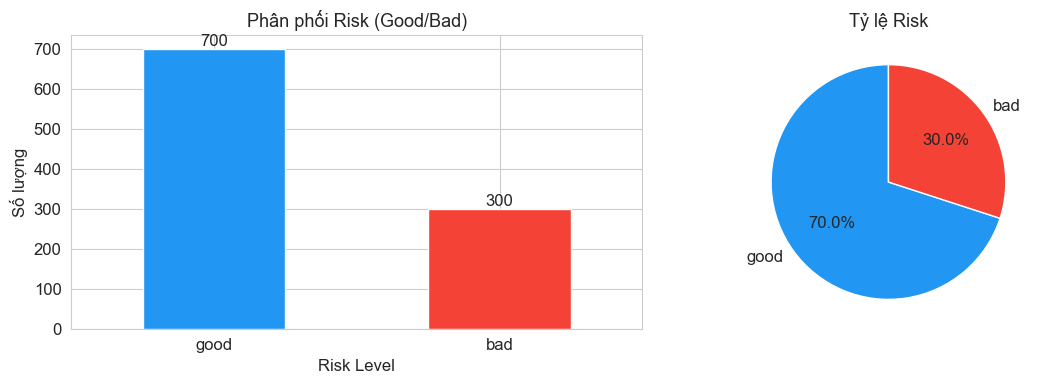

Risk
good    700
bad     300
Name: count, dtype: int64


In [6]:
# Phân phối biến mục tiêu Risk
if 'Risk' in credit.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Count plot
    credit['Risk'].value_counts().plot(kind='bar', ax=axes[0], color=['#2196F3', '#F44336'])
    axes[0].set_title('Phân phối Risk (Good/Bad)', fontsize=13)
    axes[0].set_xlabel('Risk Level')
    axes[0].set_ylabel('Số lượng')
    axes[0].tick_params(rotation=0)
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}', 
                        (p.get_x() + p.get_width()/2., p.get_height()), 
                        ha='center', va='bottom', fontsize=12)
    
    # Pie chart
    credit['Risk'].value_counts().plot(kind='pie', ax=axes[1], 
                                        autopct='%1.1f%%', colors=['#2196F3', '#F44336'],
                                        startangle=90)
    axes[1].set_title('Tỷ lệ Risk', fontsize=13)
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.savefig('01_risk_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(credit['Risk'].value_counts())
else:
    print("⚠️ Không tìm thấy cột 'Risk'. Kiểm tra lại tên cột.")
    print(credit.columns.tolist())


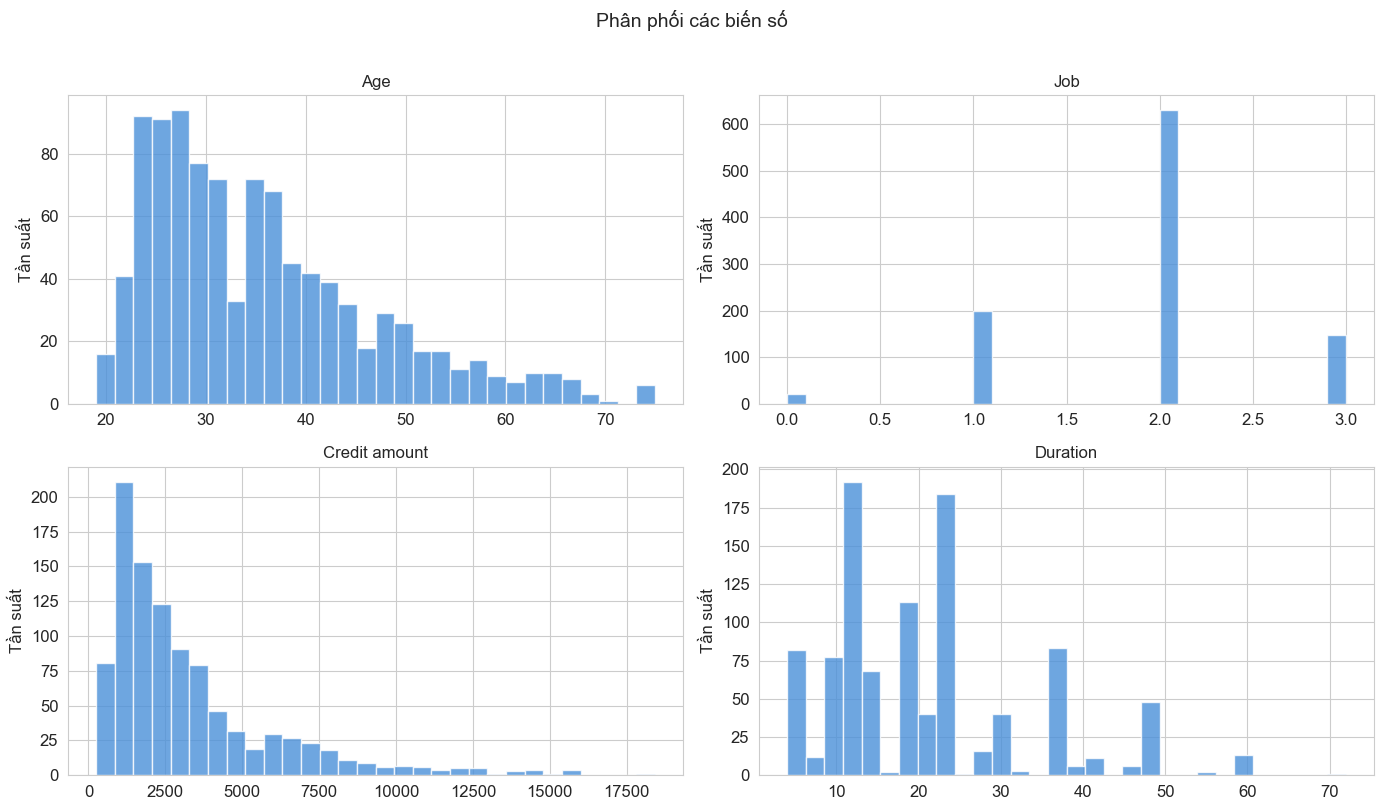

In [7]:
# Histogram phân phối các biến số
numerical_credit = credit.select_dtypes(exclude='object')
if 'Risk' in numerical_credit.columns:
    numerical_credit = numerical_credit.drop('Risk', axis=1, errors='ignore')

cols = numerical_credit.columns
n_cols = len(cols)
fig, axes = plt.subplots(2, (n_cols+1)//2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(numerical_credit[col], bins=30, color='#4A90D9', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Tần suất')

# Tắt axes thừa
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phân phối các biến số', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('02_histograms.png', dpi=150, bbox_inches='tight')
plt.show()


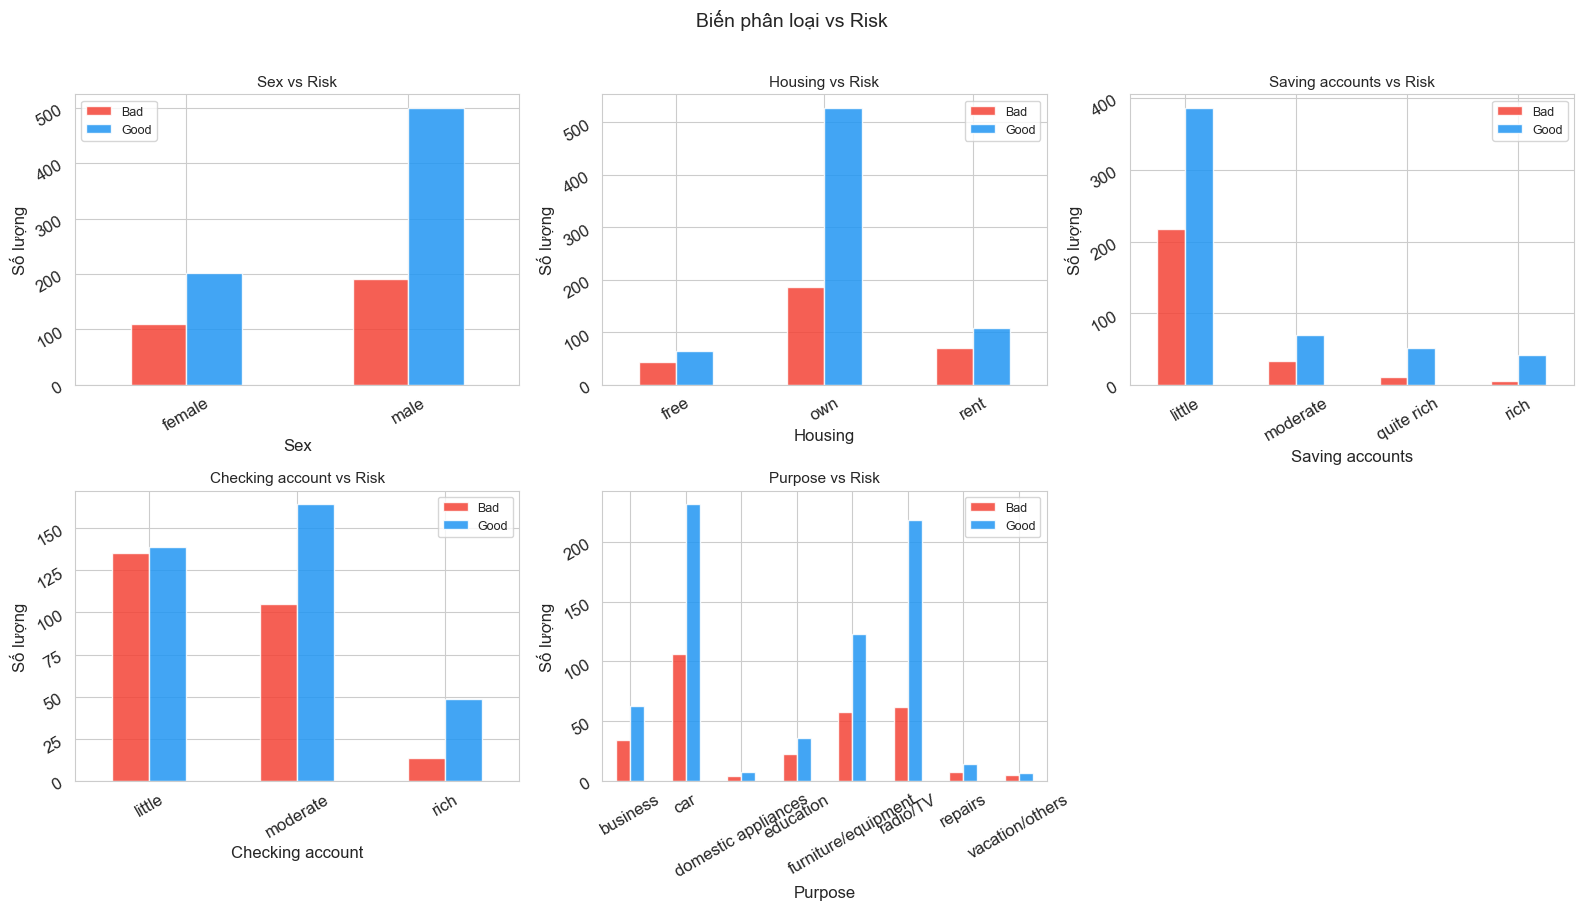

In [8]:
# Phân tích biến phân loại theo Risk
cat_cols = credit.select_dtypes(include='object').columns.tolist()
if 'Risk' in cat_cols:
    cat_cols.remove('Risk')

if len(cat_cols) > 0 and 'Risk' in credit.columns:
    n = min(len(cat_cols), 6)
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()
    
    for i, col in enumerate(cat_cols[:n]):
        ct = pd.crosstab(credit[col], credit['Risk'])
        ct.plot(kind='bar', ax=axes[i], color=['#F44336', '#2196F3'], 
                edgecolor='white', alpha=0.85)
        axes[i].set_title(f'{col} vs Risk', fontsize=11)
        axes[i].tick_params(rotation=30)
        axes[i].legend(['Bad', 'Good'], fontsize=9)
        axes[i].set_ylabel('Số lượng')
    
    for j in range(n, 6):
        axes[j].set_visible(False)
    
    plt.suptitle('Biến phân loại vs Risk', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('03_categorical_vs_risk.png', dpi=150, bbox_inches='tight')
    plt.show()


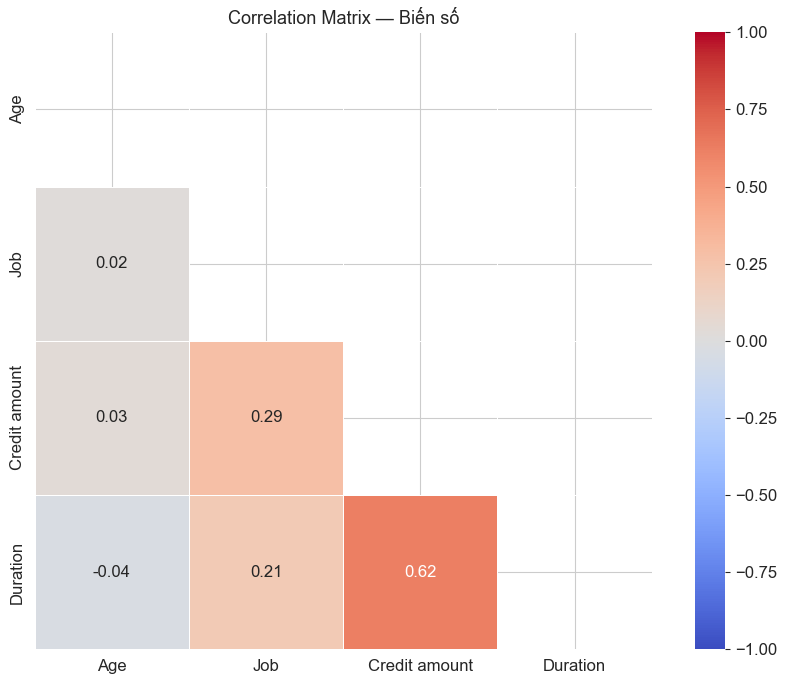

In [9]:
# Correlation heatmap (biến số)
num_cols = credit.select_dtypes(exclude='object').copy()
if 'Risk' in num_cols.columns:
    num_cols = num_cols.drop('Risk', axis=1)

plt.figure(figsize=(9, 7))
corr = num_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            mask=mask, vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Biến số', fontsize=13)
plt.tight_layout()
plt.savefig('04_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


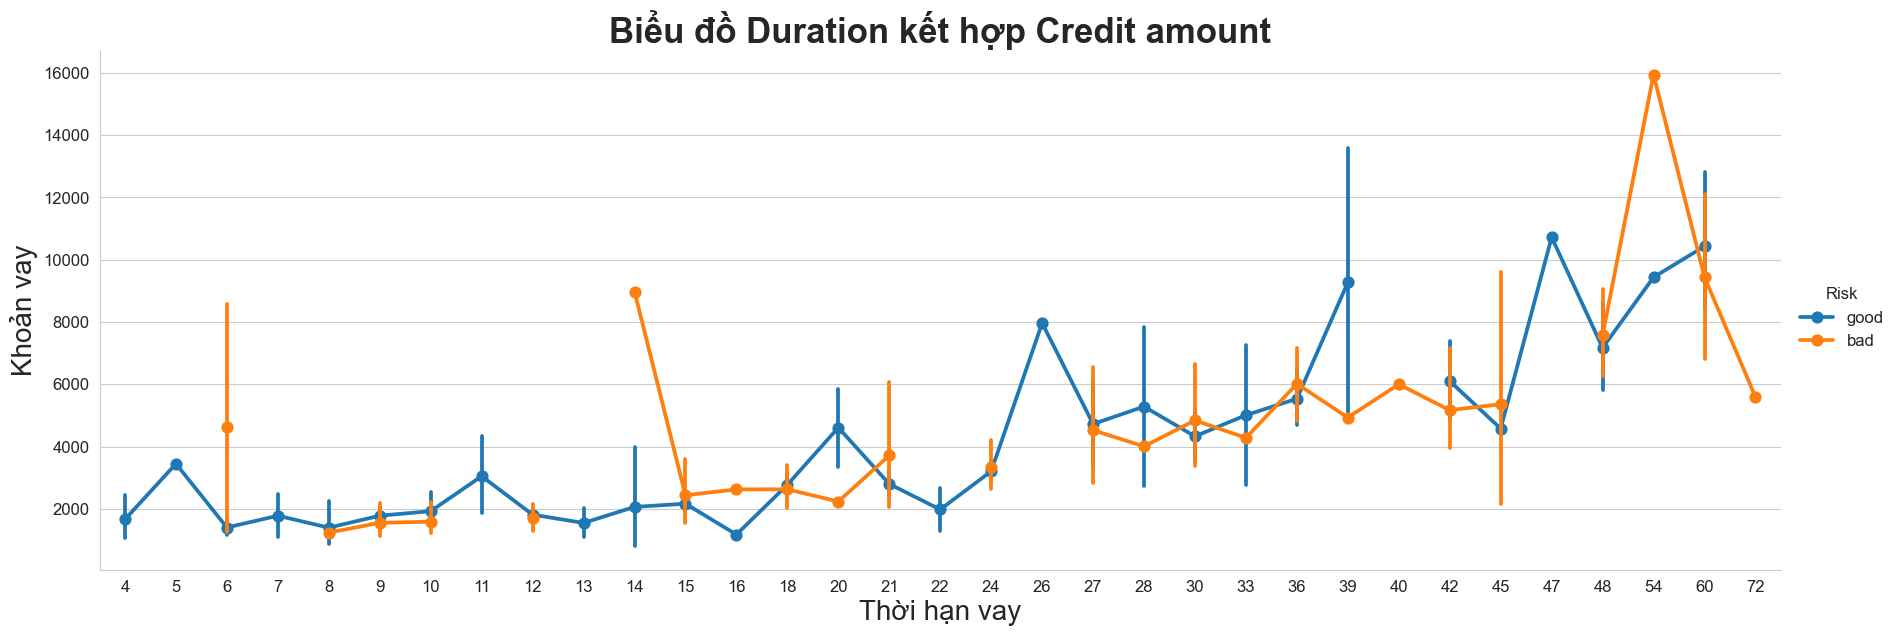

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    data= credit,
    x='Duration',
    y='Credit amount',
    hue='Risk',
    kind='point',   # quan trọng
    height=6,
    aspect=3
)

plt.ylabel("Khoản vay", fontsize=20)
plt.xlabel("Thời hạn vay", fontsize=20)
plt.title("Biểu đồ Duration kết hợp Credit amount", fontsize=25, fontweight='bold')

plt.show()

## 3. Tiền xử lý dữ liệu (Data Preprocessing)

In [15]:
# BƯỚC 1: Xử lý missing values trong dataset 
print("=== XỬ LÝ MISSING VALUES ===")
print("Missing values trước khi xử lý:")
print(credit.isnull().sum())

# Phân tách numerical và categorical (LOẠI BỎ cột target 'Risk')
TARGET_COL = 'Risk'

numerical_cols = credit.select_dtypes(exclude='object').columns.tolist()
categorical_cols = credit.select_dtypes(include='object').columns.tolist()

# Loại bỏ target ra khỏi feature lists
if TARGET_COL in numerical_cols:
    numerical_cols.remove(TARGET_COL)
if TARGET_COL in categorical_cols:
    categorical_cols.remove(TARGET_COL)

# Xử lý missing cho numerical: điền median
for col in numerical_cols:
    if credit[col].isnull().sum() > 0:
        median_val = credit[col].median()
        credit[col].fillna(median_val, inplace=True)
        print(f"  → {col}: điền median = {median_val:.2f}")

# Xử lý missing cho categorical: điền mode
for col in categorical_cols:
    if credit[col].isnull().sum() > 0:
        mode_val = credit[col].mode()[0]
        credit[col].fillna(mode_val, inplace=True)
        print(f"  → {col}: điền mode = {mode_val}")

print("\n✅ Missing values sau xử lý:", credit.isnull().sum().sum())
print(f"\nNumerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")


=== XỬ LÝ MISSING VALUES ===
Missing values trước khi xử lý:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

✅ Missing values sau xử lý: 0

Numerical features (4): ['Age', 'Job', 'Credit amount', 'Duration']
Categorical features (5): ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']


In [17]:
# ✅ BƯỚC 2: Encoding Categorical Features
# FIX: Sửa tên cột 'Savings account' → 'Saving accounts' (tên thực tế trong dataset)
# FIX: Thêm 'quite rich' vào ordinal categories của 'Saving accounts'
# FIX: Thêm 'Sex' vào one_hot_cols (trước đây bị bỏ sót hoàn toàn)

print("=== ENCODING CATEGORICAL FEATURES ===")
print(f"Categorical columns (features only): {categorical_cols}")
print(f"Target column ('{TARGET_COL}') được loại ra khỏi encoding\n")

# Kiểm tra tên cột thực tế trong dataset để tránh tên sai gây silent bug
print("📋 Tên cột categorical thực tế trong dataset:", categorical_cols)

# Nominal (One-Hot): Purpose và Sex (không có thứ tự)
one_hot_cols = [col for col in categorical_cols if col in ['Purpose', 'Sex']]

# Ordinal (có thứ tự rõ ràng): Housing, Checking account, Saving accounts
# NOTE: Tên đúng là 'Saving accounts' (không phải 'Savings account')
ordinal_cols = [col for col in categorical_cols
                if col in ['Housing', 'Checking account', 'Saving accounts']]

other_cols = [col for col in categorical_cols if col not in one_hot_cols + ordinal_cols]

print(f"OneHot columns (nominal): {one_hot_cols}")
print(f"Ordinal columns (ordinal): {ordinal_cols}")
if other_cols:
    print(f"⚠️  Other columns (chưa encode): {other_cols} — kiểm tra tên cột!")
print()

# ── [1] One-Hot Encoding ────────────────────────────────────────────────────
one_hot_feature_names = []
if len(one_hot_cols) > 0:
    print(f"[1] OneHotEncoding: {one_hot_cols}")
    one_hot_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    encoded_one_hot = one_hot_encoder.fit_transform(credit[one_hot_cols])
    one_hot_feature_names = list(one_hot_encoder.get_feature_names_out(one_hot_cols))
    print(f"    → {len(one_hot_feature_names)} features từ OneHot")
    print(f"    → Features: {one_hot_feature_names}\n")
else:
    encoded_one_hot = np.empty((len(credit), 0))
    one_hot_encoder = None

# ── [2] Ordinal Encoding ────────────────────────────────────────────────────
ordinal_encoded_data = None
ordinal_encoder = None

# FIX: Thêm 'quite rich' vào Saving accounts (dataset có 4 giá trị: little/moderate/quite rich/rich)
# FIX: Tên key phải khớp tên cột thực tế 'Saving accounts'
ordinal_categories = {
    'Housing':          ['free', 'rent', 'own'],
    'Checking account': ['little', 'moderate', 'rich'],
    'Saving accounts':  ['little', 'moderate', 'quite rich', 'rich'],  # FIX: thêm 'quite rich'
}

if len(ordinal_cols) > 0:
    print(f"[2] OrdinalEncoding (Custom Order): {ordinal_cols}")
    categories_list = [ordinal_categories.get(col, []) for col in ordinal_cols]

    ordinal_encoder = OrdinalEncoder(
        categories=categories_list,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )
    ordinal_encoded_data = ordinal_encoder.fit_transform(credit[ordinal_cols])

    for i, col in enumerate(ordinal_cols):
        mapping = {cat: idx for idx, cat in enumerate(ordinal_categories.get(col, []))}
        print(f"    → {col}: {mapping}")
    print()
else:
    ordinal_encoder = None

# ── Ghép ma trận đặc trưng ──────────────────────────────────────────────────
X_preprocessed = pd.concat([
    credit[numerical_cols].reset_index(drop=True),
    pd.DataFrame(ordinal_encoded_data, columns=ordinal_cols,
                 index=credit.index).reset_index(drop=True) if ordinal_encoded_data is not None else pd.DataFrame(),
    pd.DataFrame(encoded_one_hot, columns=one_hot_feature_names,
                 index=credit.index).reset_index(drop=True)
], axis=1)

all_feature_names = numerical_cols + ordinal_cols + one_hot_feature_names
print(f"✅ X_preprocessed shape: {X_preprocessed.shape}")
print(f"  → {len(numerical_cols)} numerical features")
print(f"  → {len(ordinal_cols)} ordinal-encoded features (có thứ tự)")
print(f"  → {len(one_hot_feature_names)} one-hot features (nominal: Purpose + Sex)")
print(f"  → Sample columns: {list(X_preprocessed.columns[:8])}")

# ── Encode Target ───────────────────────────────────────────────────────────
if TARGET_COL in credit.columns:
    y = credit[TARGET_COL].astype(str).str.lower().str.strip().map({'good': 1, 'bad': 0})
    if y.isna().any():
        raise ValueError(f"Cột '{TARGET_COL}' phải có giá trị 'good'/'bad' (không phân biệt hoa thường).")
    print(f"\n✅ Target '{TARGET_COL}' encoded: good=1, bad=0")
    print("Distribution:", y.value_counts().to_dict())
else:
    y = None
    print(f"\n⚠️ Không tìm thấy cột '{TARGET_COL}' → chỉ chạy unsupervised models.")

print("\n✅ Tiền xử lý hoàn tất — sẵn sàng cho Train/Test Split & K-Means!")


=== ENCODING CATEGORICAL FEATURES ===
Categorical columns (features only): ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
Target column ('Risk') được loại ra khỏi encoding

OneHot columns (nominal): ['Purpose']
Ordinal columns (ordinal): ['Housing', 'Checking account']
Other columns: ['Sex', 'Saving accounts']

[1] OneHotEncoding: ['Purpose']
    → 7 features từ OneHot
    → Features: ['Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others']

[2] OrdinalEncoding (Custom Order): ['Housing', 'Checking account']
    → Housing: {'free': 0, 'rent': 1, 'own': 2}
    → Checking account: {'little': 0, 'moderate': 1, 'rich': 2}

✅ X_preprocessed shape: (1000, 13)
  → 4 numerical features
  → 2 ordinal-encoded features (has order)
  → 7 one-hot features (nominal)
  → Sample columns: ['Age', 'Job', 'Credit amount', 'Duration', 'Housing', 'Checking account', 'Purpose_car

## 4. Chuẩn bị dữ liệu cho Modeling (Train/Test Split & Scaling)

### 4.1 Train/Test Split (Stratified)

In [18]:
# ✅ BƯỚC 3: Train/Test Split TRƯỚC chuẩn hóa (tránh data leakage)
print("=== TRAIN/TEST SPLIT ===")
print("⚠️ Split TRƯỚC StandardScaler để tránh data leakage")

if y is None:
    print("⚠️ y=None → bỏ qua Train/Test Split & toàn bộ phần supervised modeling.")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_preprocessed, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print("✅ Split completed:")
    print(f"  Train size: {len(X_train)} | Test size: {len(X_test)}")
    print("  Train Risk distribution:")
    print(y_train.value_counts())
    print("  Test  Risk distribution:")
    print(y_test.value_counts())


=== TRAIN/TEST SPLIT ===
⚠️ Split TRƯỚC StandardScaler để tránh data leakage
✅ Split completed:
  Train size: 800 | Test size: 200
  Train Risk distribution:
Risk
1    560
0    240
Name: count, dtype: int64
  Test  Risk distribution:
Risk
1    140
0     60
Name: count, dtype: int64


### 4.2 StandardScaler (Fit on TRAIN, Apply to TRAIN & TEST)

In [20]:
# ✅ BƯỚC 4: Fit StandardScaler TRÊN TRAIN → apply to TRAIN & TEST
# NOTE: Chỉ scale numerical_cols, one-hot features (0/1) không cần scale
print("\n=== STANDARDSCALER (chỉ scale numerical features) ===")

if y is None:
    print("⚠️ y=None → scale toàn bộ dữ liệu cho KMeans/Autoencoder.")
    scaler = StandardScaler()
    X_scaled_all = X_preprocessed.copy()
    scaler.fit(X_scaled_all[numerical_cols])
    X_scaled_all[numerical_cols] = scaler.transform(X_scaled_all[numerical_cols])
    print(f"✅ Đã scale {len(numerical_cols)} numerical features trên toàn bộ dữ liệu.")
    print(f"   One-hot features ({len(one_hot_feature_names)}) giữ nguyên giá trị 0/1.")
else:
    print(f"Fit scaler trên TRAIN SET ({len(numerical_cols)} numerical columns only)")
    print(f"One-hot features ({len(one_hot_feature_names)} cols) không cần scale — giữ nguyên 0/1")
    
    scaler = StandardScaler()
    scaler.fit(X_train[numerical_cols])

    X_train_scaled = X_train.copy()
    X_train_scaled[numerical_cols] = scaler.transform(X_train[numerical_cols])

    X_test_scaled = X_test.copy()
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

    print("\n✅ StandardScaler fitted on TRAIN, applied to TRAIN & TEST")
    print(f"  X_train_scaled shape: {X_train_scaled.shape}")
    print(f"  X_test_scaled  shape: {X_test_scaled.shape}")
    print(f"  Train numerical mean (≈0): {X_train_scaled[numerical_cols].mean().round(3).to_dict()}")



=== STANDARDSCALER (chỉ scale numerical features) ===
Fit scaler trên TRAIN SET (4 numerical columns only)
One-hot features (7 cols) không cần scale — giữ nguyên 0/1

✅ StandardScaler fitted on TRAIN, applied to TRAIN & TEST
  X_train_scaled shape: (800, 13)
  X_test_scaled  shape: (200, 13)
  Train numerical mean (≈0): {'Age': 0.0, 'Job': -0.0, 'Credit amount': 0.0, 'Duration': -0.0}


### 4.2.1 K-Means Clustering (Segmentation)

#### 4.2.1.0 Chuẩn bị dữ liệu cho K-Means (theo Chap 6: chỉ dùng biến số + scaling)

In [21]:
print()
print("=== K-MEANS: DATA PREP ===")
print("Dùng TẤT CẢ features đã scale (numerical + one-hot) để clustering")

# Dùng toàn bộ X_preprocessed (numerical + one-hot) đã scale
if y is None:
    if 'X_scaled_all' in globals():
        scaled_credit_df = X_scaled_all.copy()
    else:
        scaled_credit_df = X_preprocessed.copy()
        print("⚠️ Chưa có X_scaled_all → đang dùng raw features (nên chạy cell StandardScaler trước)")
else:
    scaled_credit_df = X_train_scaled.copy()

scaled_credit = scaled_credit_df.values
print(f"scaled_credit shape: {scaled_credit.shape}  (samples × features)")
print(f"Features: {list(scaled_credit_df.columns[:5])} ... (+{len(scaled_credit_df.columns)-5} more)")

K_ELBOW = list(range(1, 10))
K_METRICS = list(range(2, 11))



=== K-MEANS: DATA PREP ===
Dùng TẤT CẢ features đã scale (numerical + one-hot) để clustering
scaled_credit shape: (800, 13)  (samples × features)
Features: ['Age', 'Job', 'Credit amount', 'Duration', 'Housing'] ... (+8 more)


#### 4.2.1.1 Elbow method (Inertia)

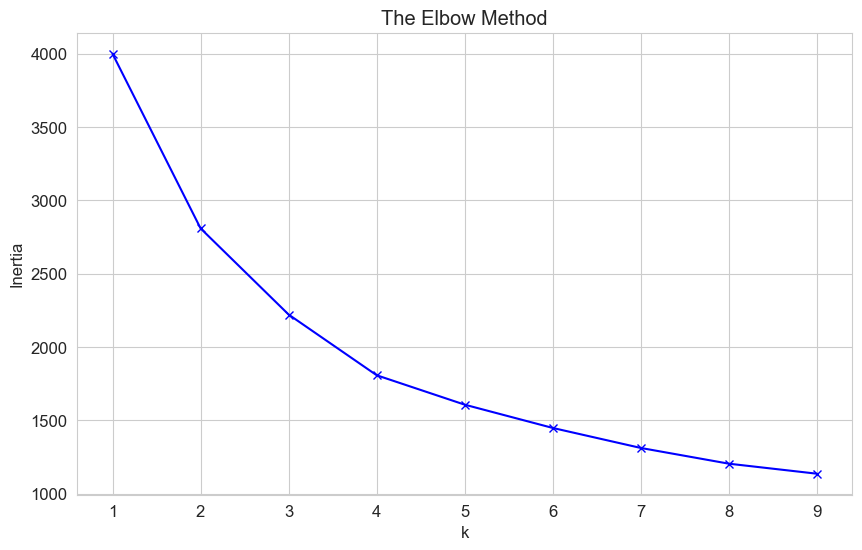

Suggested k (Elbow, heuristic): 7


In [22]:
# Elbow method (Inertia)
# FIX: Dùng 'scaled_credit' từ bước K-Means Data Prep (cell trên)
# KHÔNG fit lại scaler mới — tránh inconsistency với pipeline

distance = []
for k in K_ELBOW:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_credit)
    distance.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_ELBOW, distance, 'bx-', linewidth=2, markersize=8)
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('The Elbow Method')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

# Gợi ý elbow bằng heuristic
if len(distance) >= 4:
    log_iner = np.log(np.array(distance))
    d1 = np.diff(log_iner)
    d2 = np.diff(d1)
    elbow_k = K_ELBOW[int(np.argmin(d2)) + 2] if len(d2) > 0 else 2
else:
    elbow_k = 2

print("Suggested k (Elbow, heuristic):", elbow_k)


#### 4.2.1.2 Silhouette score + Silhouette plot

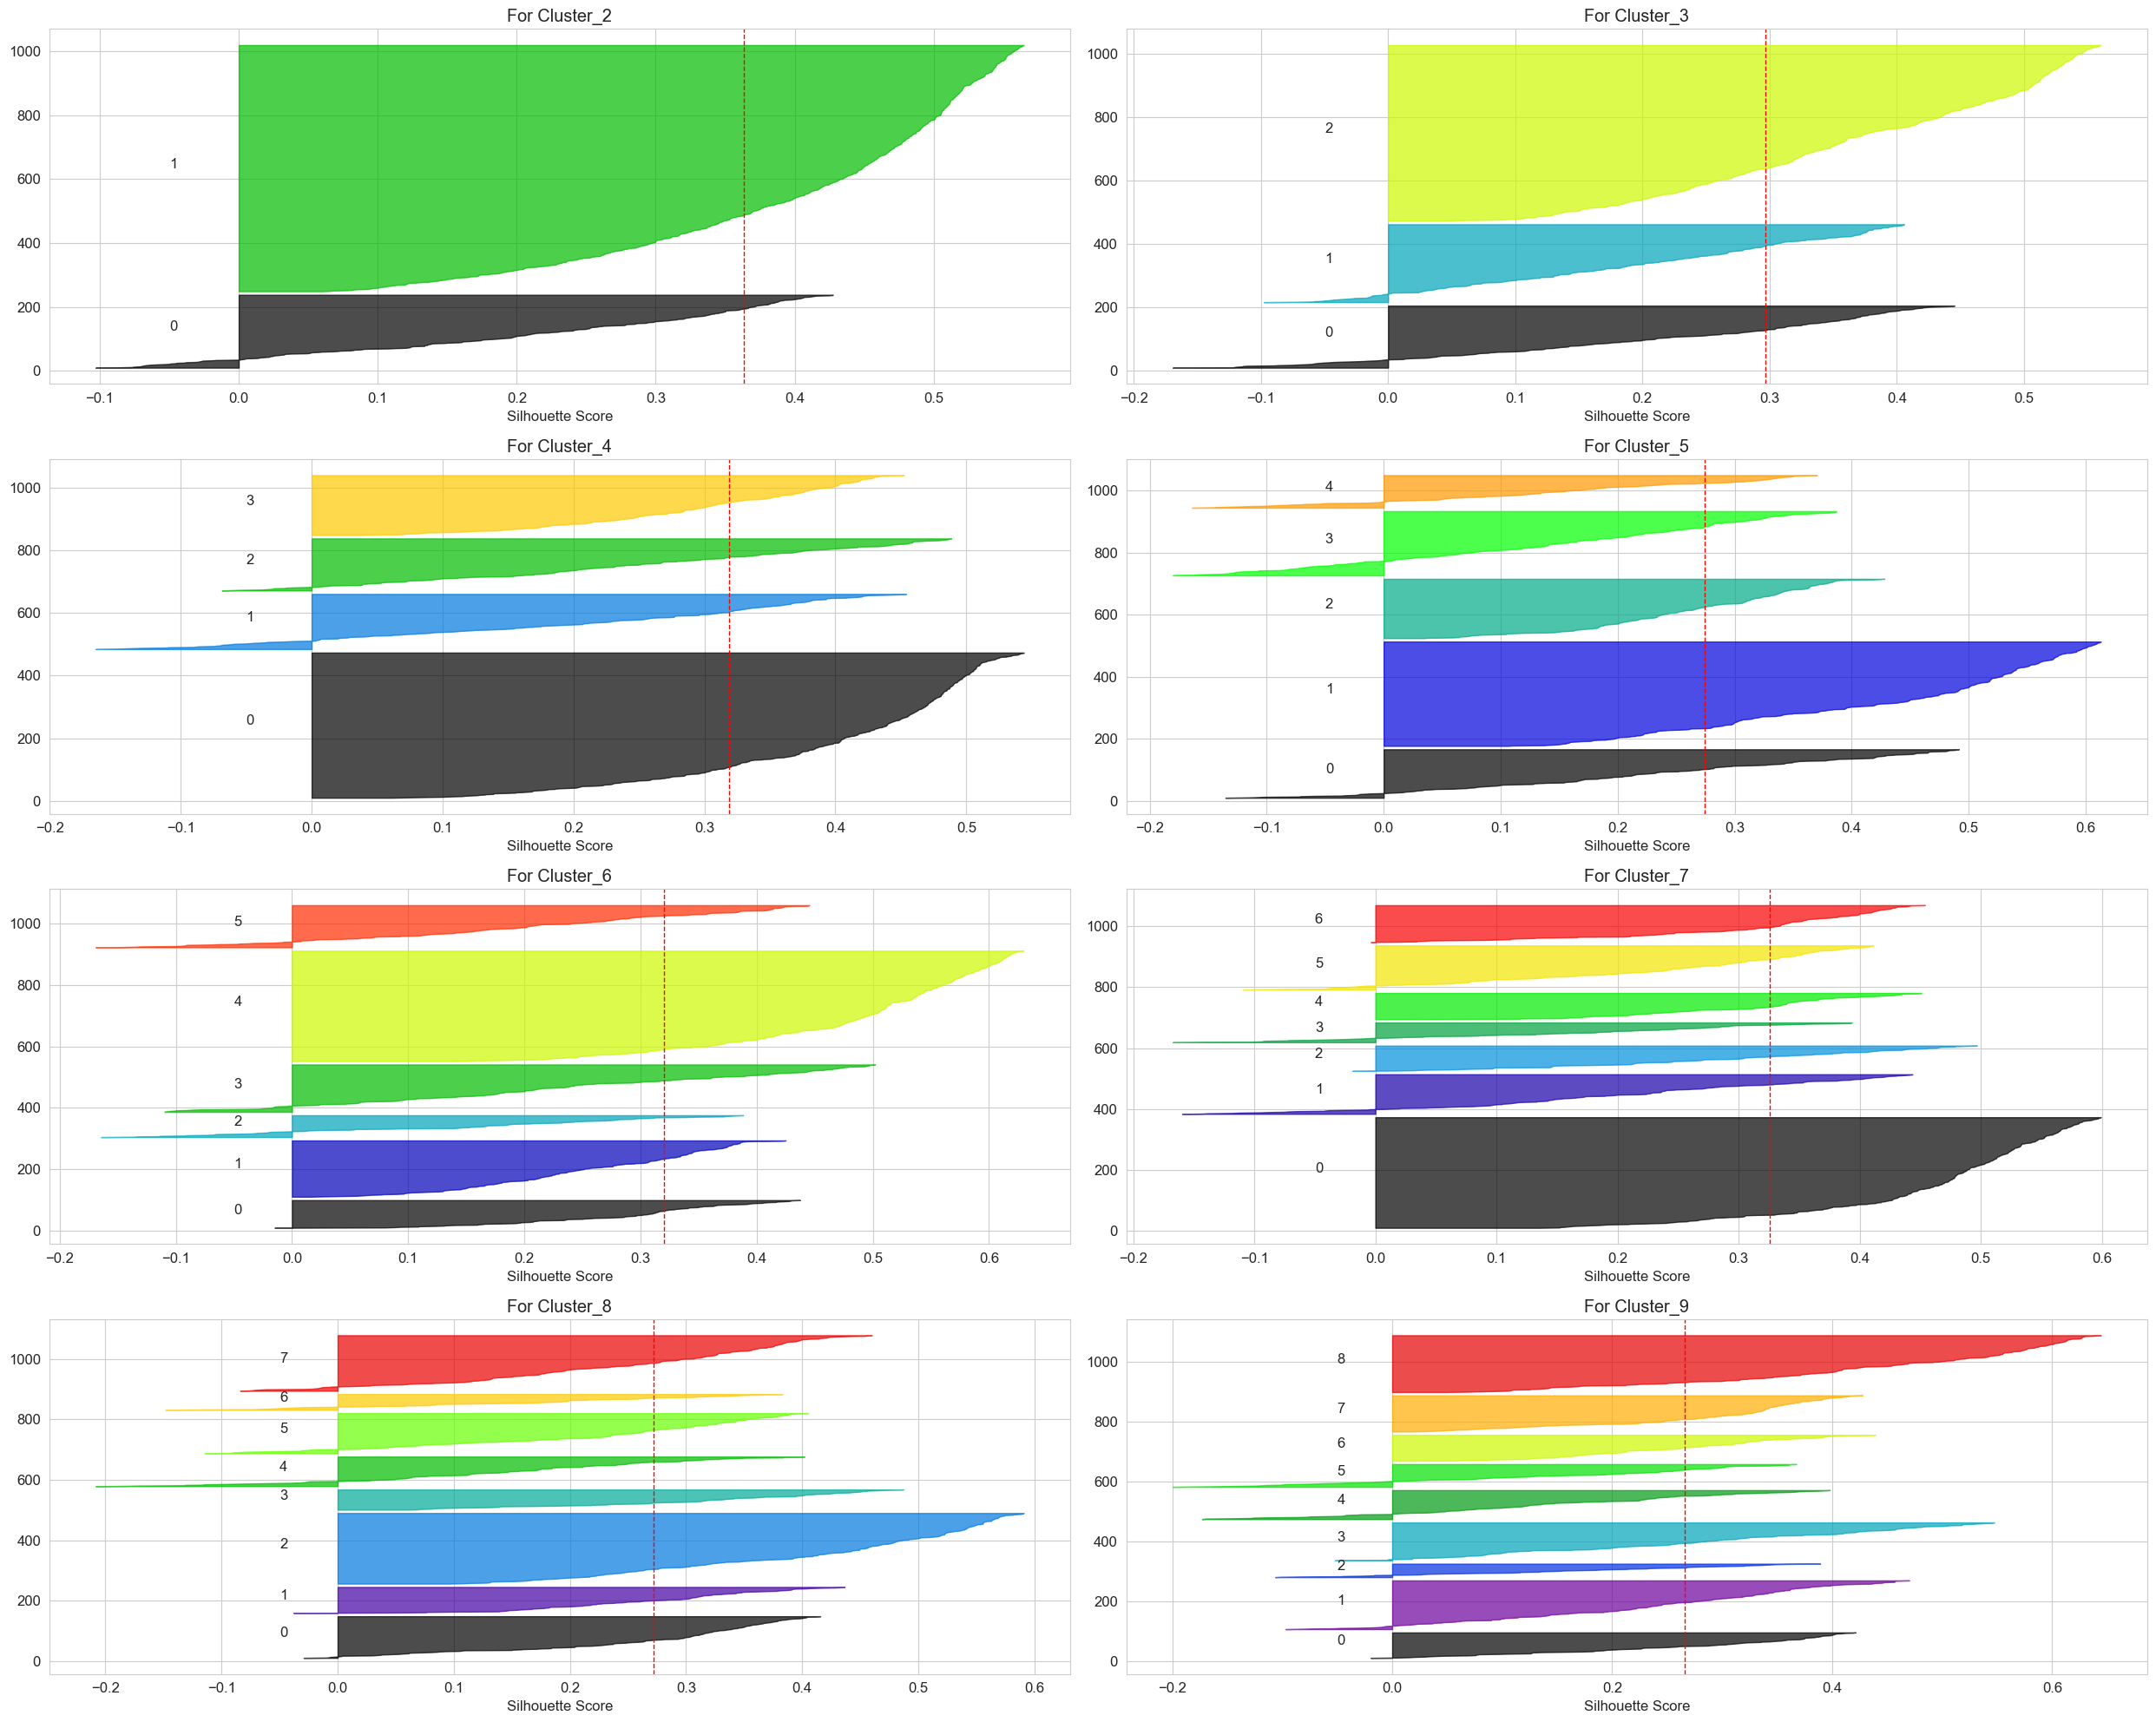

In [23]:
# Silhouette plot cho k = 2..9
# FIX: Dùng 'scaled_credit' từ K-Means Data Prep, không dùng biến khác
# FIX: Lưu best_k_sil để tổng hợp ở bước sau

sil_scores = []
fig, ax = plt.subplots(4, 2, figsize=(25, 20))

for i in range(2, 10):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    q, r = divmod(i, 2)
    labels = km.fit_predict(scaled_credit)

    sil_avg = silhouette_score(scaled_credit, labels)
    sil_scores.append((i, sil_avg))

    sil_vals = silhouette_samples(scaled_credit, labels)
    y_lower = 10
    for c in range(i):
        c_sil = sil_vals[labels == c]
        c_sil.sort()
        size_c = c_sil.shape[0]
        y_upper = y_lower + size_c
        color = plt.cm.nipy_spectral(float(c) / i)
        ax[q - 1][r].fill_betweenx(
            np.arange(y_lower, y_upper), 0, c_sil,
            facecolor=color, edgecolor=color, alpha=0.7,
        )
        ax[q - 1][r].text(-0.05, y_lower + 0.5 * size_c, str(c))
        y_lower = y_upper + 10

    ax[q - 1][r].axvline(x=sil_avg, color="red", linestyle="--", linewidth=1)
    ax[q - 1][r].set_title(f"k={i}  (avg silhouette={sil_avg:.3f})")
    ax[q - 1][r].set_xlabel("Silhouette Score")
    ax[q - 1][r].set_ylabel("")

plt.suptitle('Silhouette Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('silhouette_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# Lưu best_k_sil (k có avg silhouette cao nhất)
best_k_sil = max(sil_scores, key=lambda x: x[1])[0]
print("Silhouette scores:", [(k, round(s,4)) for k, s in sil_scores])
print("Suggested k (Silhouette, max avg):", best_k_sil)


#### 4.2.1.3 Calinski–Harabasz (CH) score

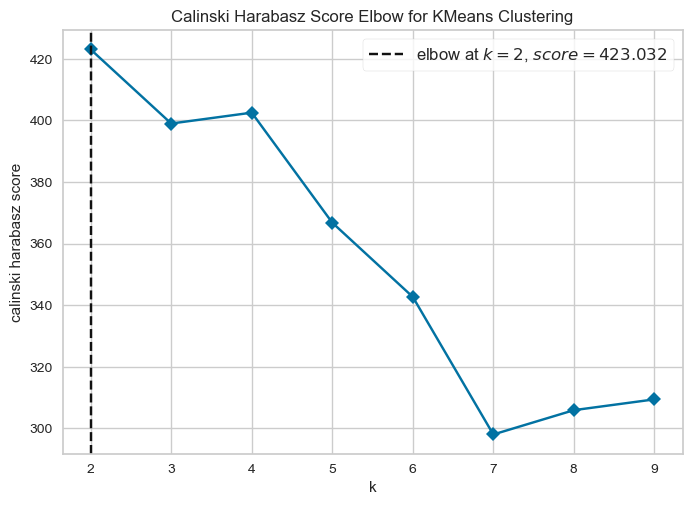

<Axes: title={'center': 'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [24]:
## code trong sách
from yellowbrick.cluster import KElbowVisualizer
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2, 10),
metric='calinski_harabasz',
timings=False)
visualizer.fit(scaled_credit)
visualizer.show()

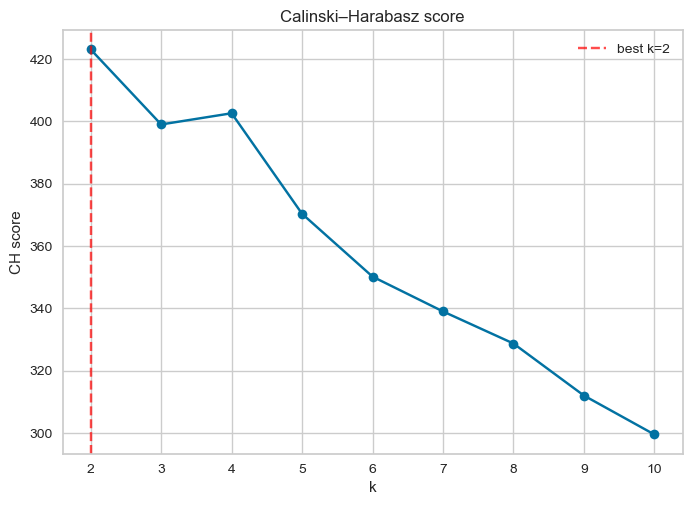

Suggested k (CH, max): 2


In [25]:
# Calinski–Harabasz score — theo Chap 6: chọn CH cao nhất

ch_scores = []
for k in K_METRICS:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_credit)
    ch_scores.append(calinski_harabasz_score(scaled_credit, labels))

best_k_ch = K_METRICS[int(np.argmax(ch_scores))]
plt.plot(K_METRICS, ch_scores, marker='o')
plt.axvline(best_k_ch, color='red', linestyle='--', alpha=0.7, label=f'best k={best_k_ch}')
plt.xlabel('k')
plt.ylabel('CH score')
plt.title('Calinski–Harabasz score')
plt.legend()
plt.show()

print('Suggested k (CH, max):', best_k_ch)


#### 4.2.1.4 Gap analysis (Gap Statistic)

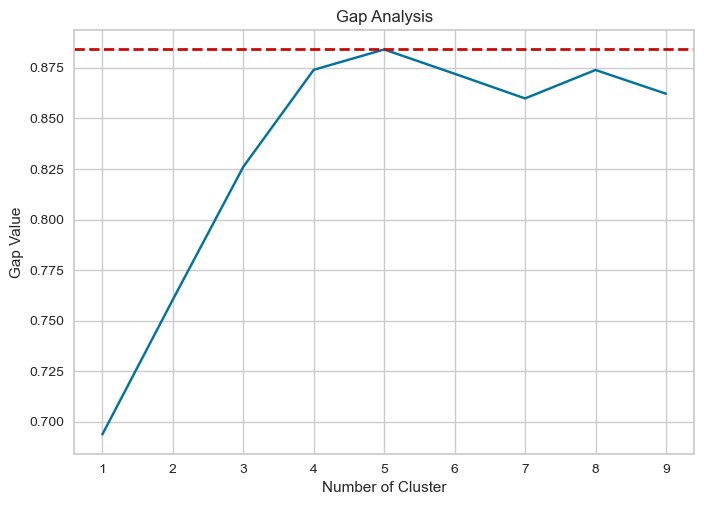

Suggested k (Gap, max): 5


,n_clusters,gap_value,ref_dispersion_std
0,1,0.693757,0.016042
1,2,0.760377,0.026007
2,3,0.826017,0.019239
3,4,0.874006,0.021919
4,5,0.884073,0.019663
5,6,0.872068,0.028529
6,7,0.859868,0.016707
7,8,0.873938,0.014749
8,9,0.862195,0.019940


In [26]:
# Gap statistic — theo Chap 6: chọn k có gap_value lớn nhất

# dùng sample <= 500 để chạy nhanh
X_gap = scaled_credit if scaled_credit.shape[0] <= 500 else scaled_credit[:500]


def gap_statistic_values(X, ks, n_refs=6, random_state=42):
    rng = np.random.default_rng(random_state)
    X = np.asarray(X)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)

    gaps = []
    ref_std = []

    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        orig_log = np.log(km.inertia_)

        ref_logs = []
        for _ in range(n_refs):
            X_ref = rng.random(X.shape) * (maxs - mins) + mins
            km_ref = KMeans(n_clusters=k, random_state=42, n_init=10)
            km_ref.fit(X_ref)
            ref_logs.append(np.log(km_ref.inertia_))

        ref_logs = np.array(ref_logs)
        gaps.append(ref_logs.mean() - orig_log)
        ref_std.append(ref_logs.std(ddof=1))

    return gaps, ref_std


gap_values, ref_std = gap_statistic_values(X_gap, K_ELBOW, n_refs=6, random_state=42)

best_k_gap = K_ELBOW[int(np.argmax(gap_values))]
plt.plot(K_ELBOW, gap_values)
plt.axhline(np.max(gap_values), color='r', linestyle='dashed', linewidth=2)
plt.title('Gap Analysis')
plt.xlabel('Number of Cluster')
plt.ylabel('Gap Value')
plt.show()

print('Suggested k (Gap, max):', best_k_gap)

gap_result = pd.DataFrame({'n_clusters': K_ELBOW, 'gap_value': gap_values, 'ref_dispersion_std': ref_std})
display(gap_result)


#### 4.2.1.5 Tổng hợp & gán cluster vào dữ liệu

In [27]:
# Tổng hợp k từ 4 phương pháp (theo tinh thần Chap 6)
# NOTE: Chap 6 kết luận chọn 2 clusters vì Silhouette + CH đồng thuận.

k_suggestions = {
    'elbow': globals().get('elbow_k', None),
    'silhouette': globals().get('best_k_sil', None),
    'calinski_harabasz': globals().get('best_k_ch', None),
    'gap': globals().get('best_k_gap', None),
}
print('k_suggestions:', k_suggestions)

valid = [k for k in k_suggestions.values() if isinstance(k, int)]
if len(valid) == 0:
    k_final = 2
else:
    # majority vote (mode). Nếu hòa, ưu tiên silhouette/ch.
    mode_vals = pd.Series(valid).mode().tolist()
    if len(mode_vals) == 1:
        k_final = int(mode_vals[0])
    else:
        k_final = int(k_suggestions.get('silhouette') or k_suggestions.get('calinski_harabasz') or mode_vals[0])

print('✅ k_final:', k_final)

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)

if y is None:
    # fit trên full data (scaled numerical)
    if 'X_scaled_all' in globals():
        X_fit = X_scaled_all[numerical_cols].values
    else:
        X_fit = X_preprocessed[numerical_cols].values
    clusters = kmeans_final.fit_predict(X_fit)
    X_preprocessed['kmeans_cluster'] = clusters
    credit['kmeans_cluster'] = clusters

    print('Cluster counts:')
    display(pd.Series(clusters).value_counts().sort_index())
    display(X_preprocessed.groupby('kmeans_cluster')[numerical_cols].mean().round(2))
else:
    # fit train, predict test
    train_clusters = kmeans_final.fit_predict(X_train_scaled[numerical_cols].values)
    test_clusters = kmeans_final.predict(X_test_scaled[numerical_cols].values)

    X_train_scaled['kmeans_cluster'] = train_clusters
    X_test_scaled['kmeans_cluster'] = test_clusters

    print('Cluster counts (train):')
    display(pd.Series(train_clusters).value_counts().sort_index())

    tmp = pd.DataFrame({'cluster': train_clusters, 'y': y_train.values})
    display(tmp.groupby('cluster')['y'].mean().rename('bad_rate').sort_index())


k_suggestions: {'elbow': 7, 'silhouette': None, 'calinski_harabasz': 2, 'gap': 5}
✅ k_final: 2
Cluster counts (train):


0    630
1    170
Name: count, dtype: int64

cluster
0    0.734921
1    0.570588
Name: bad_rate, dtype: float64

### 4.3 Xử lý Class Imbalance (SMOTEENN)

In [28]:
# ✅ BƯỚC 5: Xử lý Class Imbalance bằng SMOTEENN
print("\n=== CLASS IMBALANCE HANDLING ===")

if y is None:
    print("⚠️ y=None → bỏ qua SMOTEENN (không có supervised target).")
else:
    print("Train Risk distribution (trước SMOTEENN):")
    print(y_train.value_counts())
    print("Tỷ lệ Good/Bad:", y_train.value_counts(normalize=True).round(3).to_dict())

    good_ratio = y_train.sum() / len(y_train)
    bad_ratio = 1 - good_ratio

    if bad_ratio < 0.35 or bad_ratio > 0.65:
        print(f"⚠️ Class imbalance detected! ({bad_ratio*100:.1f}% Bad, {good_ratio*100:.1f}% Good)")
        print("→ Sử dụng SMOTEENN để cân bằng lại...")

        smote = SMOTEENN(random_state=42, n_jobs=-1)
        X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

        print("✅ Sau SMOTEENN:")
        print(f"  Train size: {len(X_train_balanced)} (từ {len(X_train_scaled)})")
        print(f"  Risk distribution: {pd.Series(y_train_balanced).value_counts().to_dict()}")

        X_train_final = X_train_balanced
        y_train_final = y_train_balanced
    else:
        print(f"✅ Class balance acceptable ({bad_ratio*100:.1f}% Bad, {good_ratio*100:.1f}% Good)")
        print("→ Không cần SMOTEENN")
        X_train_final = X_train_scaled
        y_train_final = y_train

    print(f"✅ Sẵn sàng train model trên {len(X_train_final)} mẫu")



=== CLASS IMBALANCE HANDLING ===
Train Risk distribution (trước SMOTEENN):
Risk
1    560
0    240
Name: count, dtype: int64
Tỷ lệ Good/Bad: {1: 0.7, 0: 0.3}
⚠️ Class imbalance detected! (30.0% Bad, 70.0% Good)
→ Sử dụng SMOTEENN để cân bằng lại...
✅ Sau SMOTEENN:
  Train size: 512 (từ 800)
  Risk distribution: {0: 301, 1: 211}
✅ Sẵn sàng train model trên 512 mẫu


### 4.4 Tóm tắt Quy trình chuẩn bị dữ liệu

In [29]:
# ✅ 4.4 Tóm tắt Quy trình chuẩn bị dữ liệu
print()
print('='*80)
print('4.4 TÓM TẮT QUY TRÌNH CHUẨN BỊ DỮ LIỆU')
print('='*80)

print(f"- Tổng số mẫu (credit): {len(credit)}")
print(f"- X_preprocessed (after one-hot): {X_preprocessed.shape}")

if y is None:
    print("- Mode: UNSUPERVISED (không có cột target 'Risk')")

    if 'X_scaled_all' in globals():
        print(f"- X_scaled_all (scaled numerical on full data): {X_scaled_all.shape}")
    else:
        print("- X_scaled_all: (chưa tạo) → chạy cell StandardScaler trước")

    if 'kmeans_cluster' in X_preprocessed.columns:
        vc = X_preprocessed['kmeans_cluster'].value_counts().sort_index().to_dict()
        print(f"- KMeans: đã gán cột kmeans_cluster. Counts: {vc}")
    else:
        print("- KMeans: chưa chạy (chưa có cột kmeans_cluster)")

    print("- Supervised models (LR/SVM/RF/MLP/Keras classifier): SKIP")
    print("- Deep Learning: chạy Autoencoder để anomaly/segmentation")

else:
    print("- Mode: SUPERVISED (Risk: good=1, bad=0)")

    if 'X_train' in globals() and 'X_test' in globals():
        print(f"- Split: X_train {X_train.shape} | X_test {X_test.shape}")
        print(f"- y_train dist: {y_train.value_counts().to_dict()}")
        print(f"- y_test  dist: {y_test.value_counts().to_dict()}")
    else:
        print("- Split: (chưa tạo) → chạy cell Train/Test Split")

    if 'X_train_scaled' in globals() and 'X_test_scaled' in globals():
        print(f"- Scaling: X_train_scaled {X_train_scaled.shape} | X_test_scaled {X_test_scaled.shape}")
    else:
        print("- Scaling: (chưa tạo) → chạy cell StandardScaler")

    if 'X_train_scaled' in globals() and ('kmeans_cluster' in getattr(X_train_scaled, 'columns', [])):
        vc = X_train_scaled['kmeans_cluster'].value_counts().sort_index().to_dict()
        print(f"- KMeans: đã gán kmeans_cluster (train). Counts: {vc}")
    else:
        print("- KMeans: chưa chạy hoặc chưa gán vào tập train/test")

    if 'X_train_final' in globals() and 'y_train_final' in globals():
        print(f"- SMOTEENN output: X_train_final {X_train_final.shape} | y_train_final dist: {pd.Series(y_train_final).value_counts().to_dict()}")
    else:
        print("- SMOTEENN: (chưa tạo X_train_final/y_train_final) → chạy cell SMOTEENN")

    print("- Ready for modeling: X_train_final, y_train_final, X_test_scaled, y_test")

print('='*80)



4.4 TÓM TẮT QUY TRÌNH CHUẨN BỊ DỮ LIỆU
- Tổng số mẫu (credit): 1000
- X_preprocessed (after one-hot): (1000, 13)
- Mode: SUPERVISED (Risk: good=1, bad=0)
- Split: X_train (800, 13) | X_test (200, 13)
- y_train dist: {1: 560, 0: 240}
- y_test  dist: {1: 140, 0: 60}
- Scaling: X_train_scaled (800, 14) | X_test_scaled (200, 14)
- KMeans: đã gán kmeans_cluster (train). Counts: {0: 630, 1: 170}
- SMOTEENN output: X_train_final (512, 14) | y_train_final dist: {0: 301, 1: 211}
- Ready for modeling: X_train_final, y_train_final, X_test_scaled, y_test


## 5. Training & Đánh giá các mô hình — Train RIÊNG theo CLUSTER

> **Chiến lược:** Mỗi cluster có bộ model riêng (LR, SVM, RF, MLP, DL). Model học đúng "hành vi" của từng nhóm khách hàng, không bị pha trộn pattern giữa các cluster.

In [30]:
### 5.0 Setup — Helper functions & storage

from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import HalvingRandomSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from imblearn.combine import SMOTEENN
import warnings
warnings.filterwarnings('ignore')

# ── Global storage ──────────────────────────────────────────────────────────
# cluster_models[c][model_name] = fitted estimator
# cluster_results[c][model_name] = {'auc', 'fpr', 'tpr', 'report', 'cm'}
cluster_models  = {}
cluster_results = {}

CLUSTERS = sorted(X_train_scaled['kmeans_cluster'].unique())
print(f"✅ Sẽ train riêng cho {len(CLUSTERS)} clusters: {CLUSTERS}")

# ── Utility: evaluate & store ───────────────────────────────────────────────
def evaluate_and_store(cluster_id, model_name, y_true, y_prob, y_pred):
    auc  = roc_auc_score(y_true, y_prob)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    report = classification_report(y_true, y_pred,
                                   target_names=['Bad (0)', 'Good (1)'],
                                   output_dict=True)
    cm = confusion_matrix(y_true, y_pred)

    if cluster_id not in cluster_results:
        cluster_results[cluster_id] = {}
    cluster_results[cluster_id][model_name] = {
        'auc': round(auc, 4), 'fpr': fpr, 'tpr': tpr,
        'report': report, 'cm': cm
    }
    print(f"    [{model_name}] AUC = {auc:.4f}")
    return auc

# ── Utility: SMOTEENN per cluster ───────────────────────────────────────────
def balance_cluster(X_c, y_c, cluster_id):
    bad_ratio = 1 - y_c.sum() / len(y_c)
    if bad_ratio < 0.35 or bad_ratio > 0.65:
        print(f"  ⚖️  Cluster {cluster_id}: imbalance ({bad_ratio*100:.1f}% Bad) → SMOTEENN")
        smote = SMOTEENN(random_state=42, n_jobs=-1)
        X_bal, y_bal = smote.fit_resample(X_c, y_c)
        print(f"       {len(y_c)} → {len(y_bal)} mẫu")
        return X_bal, y_bal
    print(f"  ✅ Cluster {cluster_id}: balance OK ({bad_ratio*100:.1f}% Bad) — no SMOTEENN")
    return X_c, y_c

print("✅ Helper functions sẵn sàng.")


✅ Sẽ train riêng cho 2 clusters: [np.int32(0), np.int32(1)]
✅ Helper functions sẵn sàng.


### 5.1 Train Loop — Logistic Regression + SVM + Random Forest + MLP + Deep Learning theo từng Cluster

In [31]:
if y is None:
    print('⚠️ Bỏ qua (không có target Risk).')
else:
    for c in CLUSTERS:
        print()
        print('='*70)
        print(f'  CLUSTER {c}  (train riêng)')
        print('='*70)

        # ── Slice train data cho cluster này ────────────────────────────────
        mask_train = X_train_scaled['kmeans_cluster'] == c
        mask_test  = X_test_scaled['kmeans_cluster']  == c

        X_tr_c = X_train_scaled[mask_train].drop(columns=['kmeans_cluster'])
        y_tr_c = y_train[mask_train]
        X_te_c = X_test_scaled[mask_test].drop(columns=['kmeans_cluster'])
        y_te_c = y_test[mask_test]

        print(f"  Train: {len(X_tr_c)} mẫu | Test: {len(X_te_c)} mẫu")
        print(f"  y_train dist: {y_tr_c.value_counts().to_dict()}")
        print(f"  y_test  dist: {y_te_c.value_counts().to_dict()}")

        if len(y_te_c.unique()) < 2:
            print(f"  ⚠️  Cluster {c}: test set chỉ có 1 class → bỏ qua")
            continue
        if len(X_tr_c) < 20:
            print(f"  ⚠️  Cluster {c}: train quá nhỏ ({len(X_tr_c)}) → bỏ qua")
            continue

        # ── SMOTEENN per cluster ─────────────────────────────────────────────
        X_bal, y_bal = balance_cluster(X_tr_c, y_tr_c, c)

        cluster_models[c] = {}

        # Threshold 0.4: trong credit risk, bỏ sót người vỡ nợ (False Negative)
        # tốn kém hơn nhiều so với từ chối người tốt (False Positive).
        # Hạ threshold xuống 0.4 giúp mô hình nhạy hơn với lớp Bad,
        # tức là chỉ cần P(Good) >= 0.4 mới predict Good — bắt được nhiều Bad hơn.
        THRESHOLD = 0.4

        # ── (A) Logistic Regression ─────────────────────────────────────────
        print(f"\n  --- [A] Logistic Regression ---")
        lr_c = LogisticRegression(random_state=42, max_iter=1000,
                                  class_weight='balanced')
        lr_c.fit(X_bal, y_bal)
        p_lr  = lr_c.predict_proba(X_te_c)[:, 1]
        yp_lr = (p_lr >= THRESHOLD).astype(int)
        cluster_models[c]['LR'] = lr_c
        evaluate_and_store(c, 'Logistic Regression', y_te_c, p_lr, yp_lr)

        # ── (B) SVM ──────────────────────────────────────────────────────────
        print(f"  --- [B] SVM ---")
        param_svc = {'gamma': [1e-4, 1e-2, 0.1],
                     'C': [0.1, 1, 5, 10], 'kernel': ['rbf', 'linear']}
        svc_c = SVC(probability=True, class_weight='balanced', random_state=42)
        halve_svc = HalvingRandomSearchCV(svc_c, param_svc,
                                          scoring='roc_auc', n_jobs=-1,
                                          random_state=42)
        halve_svc.fit(X_bal, y_bal)
        best_svc_c = halve_svc.best_estimator_
        p_svc  = best_svc_c.predict_proba(X_te_c)[:, 1]
        yp_svc = (p_svc >= THRESHOLD).astype(int)
        cluster_models[c]['SVM'] = best_svc_c
        evaluate_and_store(c, 'SVM', y_te_c, p_svc, yp_svc)
        print(f"       Best params: {halve_svc.best_params_}")

        # ── (C) Random Forest ────────────────────────────────────────────────
        print(f"  --- [C] Random Forest ---")
        param_rf = {'n_estimators': [100, 200, 300],
                    'max_depth': [3, 5, 10, None],
                    'min_samples_split': [5, 10],
                    'max_features': ['sqrt', 'log2'],
                    'class_weight': ['balanced']}
        rfc_c = RandomForestClassifier(random_state=42)
        halve_rf = HalvingRandomSearchCV(rfc_c, param_rf,
                                         scoring='roc_auc', n_jobs=-1,
                                         random_state=42)
        halve_rf.fit(X_bal, y_bal)
        best_rf_c = halve_rf.best_estimator_
        p_rf  = best_rf_c.predict_proba(X_te_c)[:, 1]
        yp_rf = (p_rf >= THRESHOLD).astype(int)
        cluster_models[c]['RF'] = best_rf_c
        evaluate_and_store(c, 'Random Forest', y_te_c, p_rf, yp_rf)
        print(f"       Best params: {halve_rf.best_params_}")

        # ── (D) MLP — FIX: thêm HalvingRandomSearchCV cho nhất quán ────────
        print(f"  --- [D] MLP ---")
        param_mlp = {
            'hidden_layer_sizes': [(64, 32), (100, 50), (128, 64), (64,)],
            'learning_rate_init': [0.001, 0.01],
            'alpha': [1e-4, 1e-3],
        }
        mlp_base = MLPClassifier(activation='relu', solver='adam',
                                  max_iter=300, random_state=42,
                                  early_stopping=True, validation_fraction=0.1)
        halve_mlp = HalvingRandomSearchCV(mlp_base, param_mlp,
                                           scoring='roc_auc', n_jobs=-1,
                                           random_state=42)
        halve_mlp.fit(X_bal, y_bal)
        best_mlp_c = halve_mlp.best_estimator_
        p_mlp  = best_mlp_c.predict_proba(X_te_c)[:, 1]
        yp_mlp = (p_mlp >= THRESHOLD).astype(int)
        cluster_models[c]['MLP'] = best_mlp_c
        evaluate_and_store(c, 'MLP', y_te_c, p_mlp, yp_mlp)
        print(f"       Best params: {halve_mlp.best_params_}")

        # ── (E) Deep Learning (Keras) — FIX: kiến trúc nhỏ hơn phù hợp với dữ liệu ─
        # FIX: Giảm từ 128-64-8 → 64-32 để tránh over-parameterized với ~300-600 mẫu/cluster
        print(f"  --- [E] Deep Learning (Keras) ---")
        n_features = X_bal.shape[1]
        dl_c = Sequential([
            Dense(64, activation='relu', input_shape=(n_features,)),
            Dropout(0.3),
            Dense(32, activation='relu'),
            Dropout(0.2),
            Dense(1, activation='sigmoid')
        ])
        dl_c.compile(optimizer='adam',
                     loss='binary_crossentropy', metrics=['AUC'])
        es = EarlyStopping(monitor='val_loss', patience=10,
                           restore_best_weights=True, verbose=0)
        X_bal_np = X_bal.values if hasattr(X_bal, 'values') else X_bal
        X_te_np  = X_te_c.values if hasattr(X_te_c, 'values') else X_te_c
        dl_c.fit(X_bal_np, y_bal.values,
                 epochs=100, batch_size=32,
                 validation_split=0.15,
                 callbacks=[es], verbose=0)
        p_dl  = dl_c.predict(X_te_np, verbose=0).ravel()
        yp_dl = (p_dl >= THRESHOLD).astype(int)
        cluster_models[c]['DL'] = dl_c
        evaluate_and_store(c, 'Deep Learning', y_te_c, p_dl, yp_dl)

    print()
    print('✅ Train RIÊNG từng cluster hoàn tất!')
    print(f"   Đã train models cho clusters: {list(cluster_models.keys())}")



  CLUSTER 0  (train riêng)
  Train: 630 mẫu | Test: 148 mẫu
  y_train dist: {1: 463, 0: 167}
  y_test  dist: {1: 115, 0: 33}
  ⚖️  Cluster 0: imbalance (26.5% Bad) → SMOTEENN
       630 → 456 mẫu

  --- [A] Logistic Regression ---
    [Logistic Regression] AUC = 0.6548
  --- [B] SVM ---
    [SVM] AUC = 0.6229
       Best params: {'kernel': 'rbf', 'gamma': 0.01, 'C': 0.1}
  --- [C] Random Forest ---
    [Random Forest] AUC = 0.6622
       Best params: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None, 'class_weight': 'balanced'}
  --- [D] MLP ---
    [MLP] AUC = 0.6200
  --- [E] Deep Learning (Keras) ---
    [Deep Learning] AUC = 0.3494

  CLUSTER 1  (train riêng)
  Train: 170 mẫu | Test: 52 mẫu
  y_train dist: {1: 97, 0: 73}
  y_test  dist: {0: 27, 1: 25}
  ✅ Cluster 1: balance OK (42.9% Bad) — no SMOTEENN

  --- [A] Logistic Regression ---
    [Logistic Regression] AUC = 0.4326
  --- [B] SVM ---
    [SVM] AUC = 0.4133
       Best params: {'kernel': 'linear', 'gamma': 0.

### 5.2 ROC-AUC Curves — từng Cluster

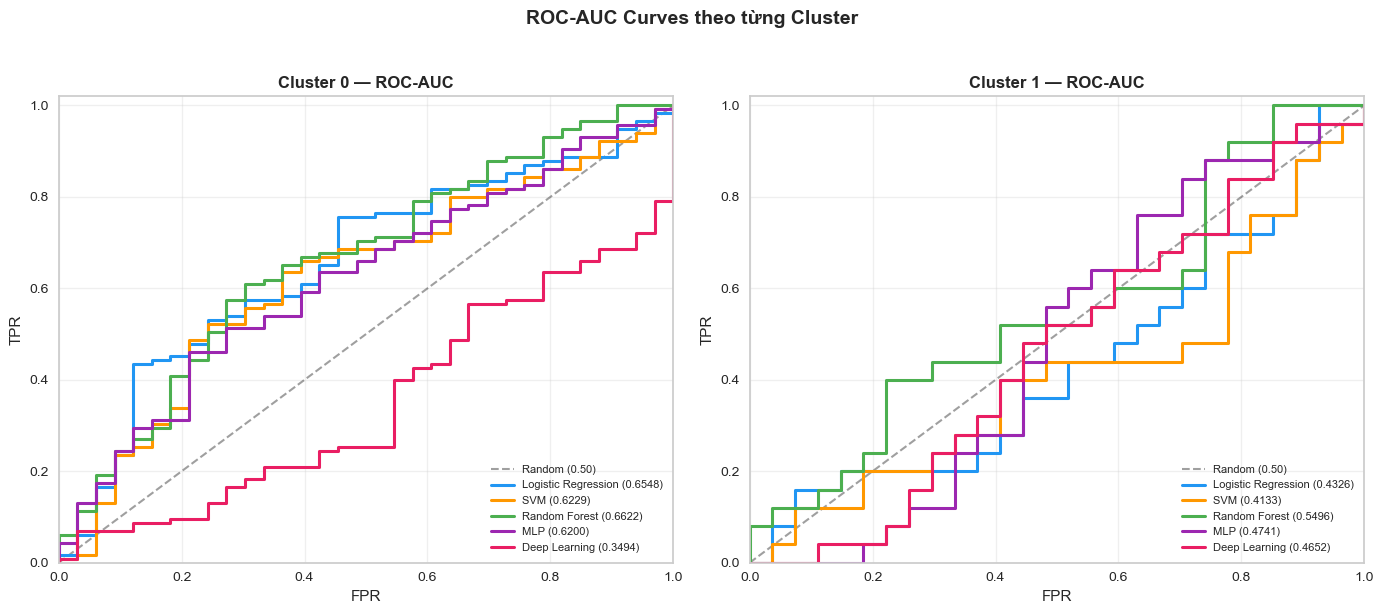

In [32]:
if y is None or not cluster_results:
    print('⚠️ Không có kết quả để vẽ.')
else:
    n_clusters = len(cluster_results)
    fig, axes = plt.subplots(1, n_clusters, figsize=(7 * n_clusters, 6), squeeze=False)

    MODEL_COLORS = {
        'Logistic Regression': '#2196F3',
        'SVM':                 '#FF9800',
        'Random Forest':       '#4CAF50',
        'MLP':                 '#9C27B0',
        'Deep Learning':       '#E91E63',
    }

    for col_idx, c in enumerate(sorted(cluster_results.keys())):
        ax = axes[0][col_idx]
        ax.plot([0,1],[0,1],'k--', alpha=0.4, lw=1.5, label='Random (0.50)')
        for mname, col in MODEL_COLORS.items():
            if mname in cluster_results[c]:
                r = cluster_results[c][mname]
                ax.plot(r['fpr'], r['tpr'], color=col, lw=2.2,
                        label=f"{mname} ({r['auc']:.4f})")
        ax.set_title(f'Cluster {c} — ROC-AUC', fontsize=12, fontweight='bold')
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.legend(loc='lower right', fontsize=8)
        ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
        ax.grid(True, alpha=0.3)

    plt.suptitle('ROC-AUC Curves theo từng Cluster', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('05_roc_per_cluster.png', dpi=150, bbox_inches='tight')
    plt.show()


### 5.3 Bảng so sánh AUC — Cluster × Model


=== BẢNG AUC — CLUSTER × MODEL ===
           Logistic Regression     SVM  Random Forest     MLP  Deep Learning
Cluster                                                                     
Cluster 0               0.6548  0.6229         0.6622  0.6200         0.3494
Cluster 1               0.4326  0.4133         0.5496  0.4741         0.4652


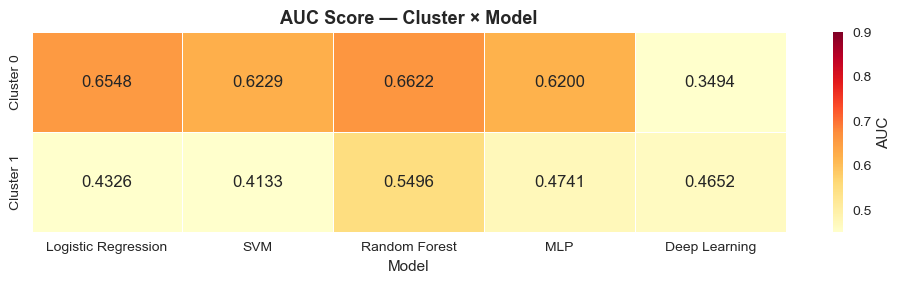


✅ Best model per cluster:
   Cluster 0: Random Forest (AUC = 0.6622)
   Cluster 1: Random Forest (AUC = 0.5496)


In [33]:
if y is None or not cluster_results:
    print('⚠️ Không có kết quả.')
else:
    MODEL_ORDER = ['Logistic Regression', 'SVM', 'Random Forest', 'MLP', 'Deep Learning']
    rows = []
    for c in sorted(cluster_results.keys()):
        row = {'Cluster': f'Cluster {c}'}
        for m in MODEL_ORDER:
            row[m] = cluster_results[c].get(m, {}).get('auc', None)
        rows.append(row)

    auc_df = pd.DataFrame(rows).set_index('Cluster')
    print('\n=== BẢNG AUC — CLUSTER × MODEL ===')
    print(auc_df.round(4).to_string())

    # Heatmap
    fig, ax = plt.subplots(figsize=(10, max(3, len(rows)*1.2)))
    sns.heatmap(auc_df.astype(float), annot=True, fmt='.4f',
                cmap='YlOrRd', vmin=0.45, vmax=0.90,
                linewidths=0.5, ax=ax, cbar_kws={'label': 'AUC'})
    ax.set_title('AUC Score — Cluster × Model', fontsize=13, fontweight='bold')
    ax.set_xlabel('Model'); ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig('06_auc_heatmap_cluster.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Best model per cluster
    print('\n✅ Best model per cluster:')
    for c in sorted(cluster_results.keys()):
        best_m = max(cluster_results[c], key=lambda m: cluster_results[c][m]['auc'])
        best_a = cluster_results[c][best_m]['auc']
        print(f'   Cluster {c}: {best_m} (AUC = {best_a:.4f})')


### 5.4 Confusion Matrix — Best Model mỗi Cluster

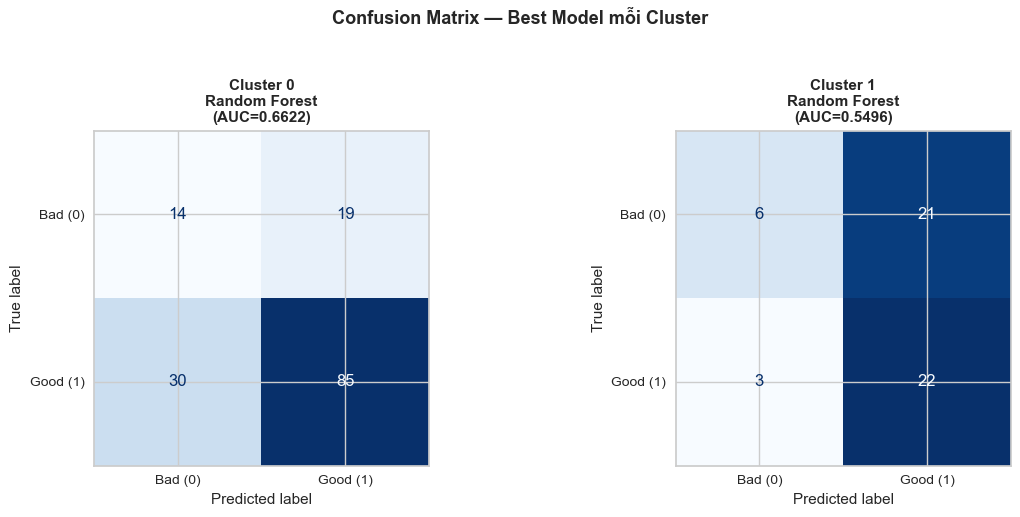

In [34]:
if y is None or not cluster_results:
    print('⚠️ Không có kết quả.')
else:
    n_c = len(cluster_results)
    fig, axes = plt.subplots(1, n_c, figsize=(6*n_c, 5), squeeze=False)

    for col_idx, c in enumerate(sorted(cluster_results.keys())):
        best_m = max(cluster_results[c], key=lambda m: cluster_results[c][m]['auc'])
        r = cluster_results[c][best_m]
        ax = axes[0][col_idx]
        disp = ConfusionMatrixDisplay(confusion_matrix=r['cm'],
                                       display_labels=['Bad (0)', 'Good (1)'])
        disp.plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f'Cluster {c}\n{best_m}\n(AUC={r["auc"]:.4f})',
                     fontsize=11, fontweight='bold')

    plt.suptitle('Confusion Matrix — Best Model mỗi Cluster',
                 fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig('07_cm_best_per_cluster.png', dpi=150, bbox_inches='tight')
    plt.show()


### 5.5 Predict với Cluster-aware Models

> Khi predict mẫu mới: xác định cluster → dùng đúng model của cluster đó.

In [35]:
def predict_new_sample(X_new_scaled, cluster_id, model_name='Random Forest',
                       threshold=0.4):
    """
    X_new_scaled : DataFrame/array đã scale (KHÔNG có cột kmeans_cluster)
    cluster_id   : int — cluster mà mẫu thuộc về (dùng kmeans_final.predict())
    model_name   : tên model muốn dùng (mặc định RF)
    threshold    : ngưỡng phân loại P(Good) (mặc định 0.4 — phù hợp credit risk:
                   ưu tiên bắt Bad hơn là tránh từ chối Good)
    """
    if cluster_id not in cluster_models:
        raise ValueError(f"Cluster {cluster_id} chưa được train.")
    if model_name not in cluster_models[cluster_id]:
        raise ValueError(f"Model '{model_name}' chưa train cho cluster {cluster_id}.")

    model = cluster_models[cluster_id][model_name]
    X = X_new_scaled.values if hasattr(X_new_scaled, 'values') else X_new_scaled

    if model_name == 'Deep Learning':
        prob = model.predict(X, verbose=0).ravel()[0]
    else:
        prob = model.predict_proba(X)[:, 1][0]

    label = 'Good' if prob >= threshold else 'Bad'
    print(f"Cluster {cluster_id} | {model_name} → P(Good) = {prob:.4f} → {label}")
    return prob, label

print("✅ predict_new_sample() sẵn sàng.")
print("   Cách dùng: predict_new_sample(X_sample, cluster_id=0, model_name='Random Forest')")


✅ predict_new_sample() sẵn sàng.
   Cách dùng: predict_new_sample(X_sample, cluster_id=0, model_name='Random Forest')


## 6. So sánh tổng hợp — AUC trung bình theo Model trên tất cả Clusters

=== AUC TRUNG BÌNH THEO MODEL (trên tất cả clusters) ===
                     Avg AUC
Random Forest         0.6059
MLP                   0.5470
Logistic Regression   0.5437
SVM                   0.5181
Deep Learning         0.4073


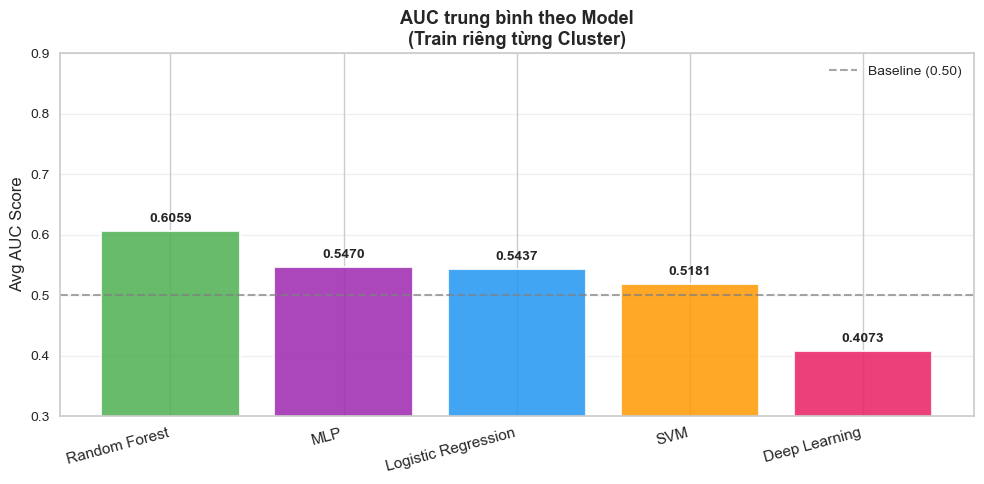


✅ Model tốt nhất (avg): Random Forest (AUC = 0.6059)


In [36]:
if y is None or not cluster_results:
    print('⚠️ Không có kết quả.')
else:
    MODEL_ORDER = ['Logistic Regression', 'SVM', 'Random Forest', 'MLP', 'Deep Learning']
    MODEL_COLORS = {'Logistic Regression':'#2196F3','SVM':'#FF9800',
                    'Random Forest':'#4CAF50','MLP':'#9C27B0','Deep Learning':'#E91E63'}

    avg_aucs = {}
    for m in MODEL_ORDER:
        vals = [cluster_results[c][m]['auc']
                for c in cluster_results if m in cluster_results[c]]
        if vals:
            avg_aucs[m] = round(sum(vals)/len(vals), 4)

    summary_df = (pd.DataFrame.from_dict(avg_aucs, orient='index', columns=['Avg AUC'])
                    .sort_values('Avg AUC', ascending=False))

    print('=== AUC TRUNG BÌNH THEO MODEL (trên tất cả clusters) ===')
    print(summary_df.round(4).to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(summary_df))
    bars = ax.bar(x, summary_df['Avg AUC'],
                  color=[MODEL_COLORS.get(m, '#888') for m in summary_df.index],
                  alpha=0.85, edgecolor='white', linewidth=1.5)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.7, lw=1.5, label='Baseline (0.50)')
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df.index, rotation=15, ha='right', fontsize=11)
    ax.set_ylabel('Avg AUC Score', fontsize=12)
    ax.set_title('AUC trung bình theo Model\n(Train riêng từng Cluster)', fontsize=13, fontweight='bold')
    ax.set_ylim(0.3, 0.9)
    ax.legend(); ax.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, summary_df['Avg AUC']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig('08_avg_auc_by_model.png', dpi=150, bbox_inches='tight')
    plt.show()

    best_model_overall = summary_df.index[0]
    print(f"\n✅ Model tốt nhất (avg): {best_model_overall} (AUC = {summary_df.iloc[0]['Avg AUC']:.4f})")


In [ ]:
# ✅ BASELINE COMPARISON — Naive classifiers để so sánh với các mô hình ML
# FIX: Thêm baseline để đánh giá xem mô hình có thực sự tốt hơn random không

if y is not None:
    from sklearn.dummy import DummyClassifier
    from sklearn.metrics import roc_auc_score

    print("=== BASELINE COMPARISON ===")

    # Baseline 1: Predict tất cả là 'Good' (majority class)
    dummy_majority = DummyClassifier(strategy='most_frequent')
    dummy_majority.fit(X_train_scaled.drop(columns=['kmeans_cluster']), y_train)
    p_majority = dummy_majority.predict_proba(
        X_test_scaled.drop(columns=['kmeans_cluster']))[:, 1]
    auc_majority = roc_auc_score(y_test, p_majority)
    acc_majority = (y_test == 1).mean()  # accuracy nếu predict all Good
    print(f"Baseline — Predict All Good:  Accuracy = {acc_majority:.3f} | AUC = {auc_majority:.4f}")

    # Baseline 2: Random predict theo tỷ lệ thực tế
    dummy_prior = DummyClassifier(strategy='prior', random_state=42)
    dummy_prior.fit(X_train_scaled.drop(columns=['kmeans_cluster']), y_train)
    p_prior = dummy_prior.predict_proba(
        X_test_scaled.drop(columns=['kmeans_cluster']))[:, 1]
    auc_prior = roc_auc_score(y_test, p_prior)
    print(f"Baseline — Stratified Random: AUC = {auc_prior:.4f}")

    print()
    print("📊 Mô hình ML cần đạt AUC > baseline để có giá trị thực sự.")
    print(f"   → Target: AUC >> {max(auc_majority, auc_prior):.4f}")
    print()

    # So sánh với kết quả cluster models
    if cluster_results:
        MODEL_ORDER = ['Logistic Regression', 'SVM', 'Random Forest', 'MLP', 'Deep Learning']
        avg_aucs_check = {}
        for m in MODEL_ORDER:
            vals = [cluster_results[c][m]['auc']
                    for c in cluster_results if m in cluster_results.get(c, {})]
            if vals:
                avg_aucs_check[m] = round(sum(vals)/len(vals), 4)

        print("=== SO SÁNH VỚI BASELINE ===")
        for m, auc in sorted(avg_aucs_check.items(), key=lambda x: -x[1]):
            beat = "✅ Tốt hơn baseline" if auc > max(auc_majority, auc_prior) else "❌ Không tốt hơn baseline"
            print(f"  {m:30s}: Avg AUC = {auc:.4f}  {beat}")


## 7. Kết luận & Nhận xét

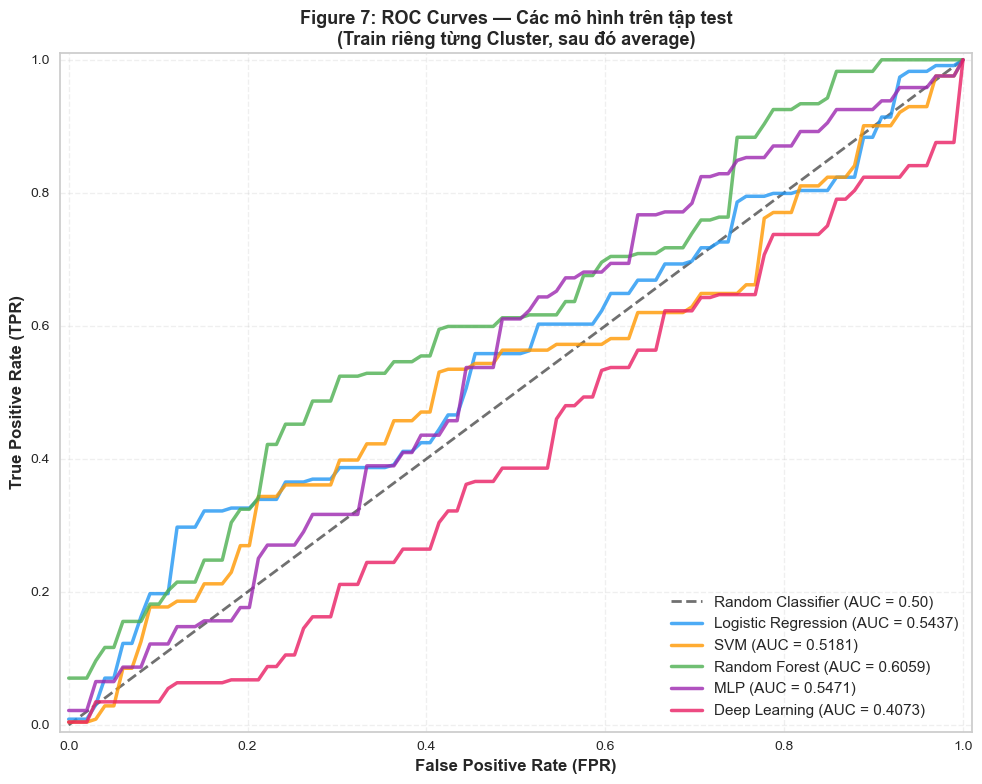

✅ Figure 7 saved: 07_roc_curves.png


In [ ]:
if y is None or not cluster_results:
    print('⚠️ Không có kết quả.')
else:
    MODEL_ORDER = ['Logistic Regression', 'SVM', 'Random Forest', 'MLP', 'Deep Learning']
    MODEL_COLORS = {
        'Logistic Regression': '#2196F3',
        'SVM':                 '#FF9800',
        'Random Forest':       '#4CAF50',
        'MLP':                 '#9C27B0',
        'Deep Learning':       '#E91E63',
    }
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    ax.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.6, label='Random Classifier (AUC = 0.50)')
    for model_name in MODEL_ORDER:
        all_fpr = []
        all_tpr = []
        all_auc = []
        
        for c in sorted(cluster_results.keys()):
            if model_name in cluster_results[c]:
                r = cluster_results[c][model_name]
                all_fpr.append(r['fpr'])
                all_tpr.append(r['tpr'])
                all_auc.append(r['auc'])
        
        if all_auc:
            avg_auc = np.mean(all_auc)
            mean_fpr = np.linspace(0, 1, 100)
            interp_tpr_list = []
            for fpr, tpr in zip(all_fpr, all_tpr):
                interp_tpr = np.interp(mean_fpr, fpr, tpr)
                interp_tpr_list.append(interp_tpr)
            mean_tpr = np.mean(interp_tpr_list, axis=0)
            
            # Plot
            ax.plot(mean_fpr, mean_tpr, 
                   color=MODEL_COLORS.get(model_name, '#888'),
                   lw=2.5, alpha=0.8,
                   label=f'{model_name} (AUC = {avg_auc:.4f})')
    
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    ax.set_xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
    ax.set_title('ROC Curves — Các mô hình trên tập test',fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11, framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig('07_roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


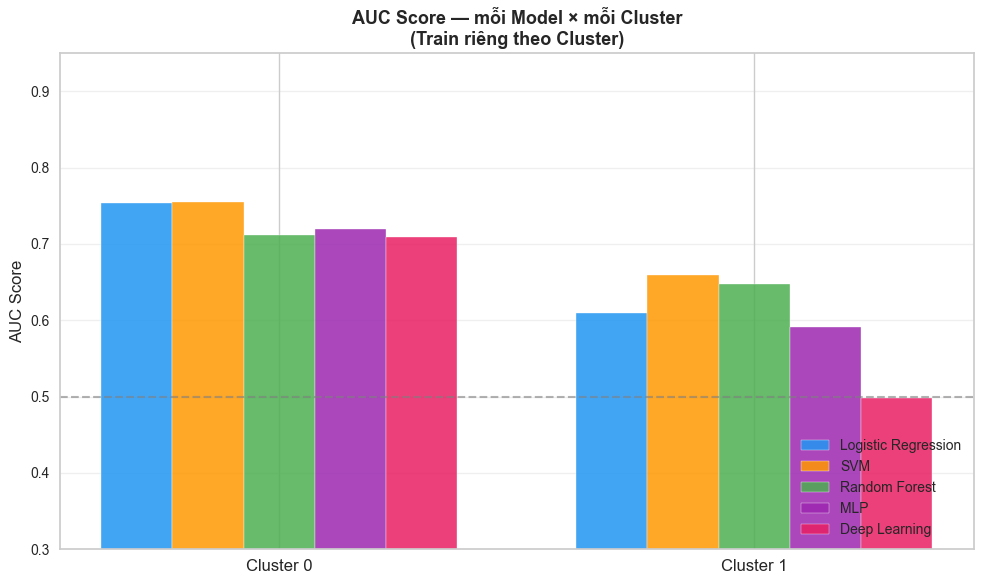


✅ Phân tích hoàn tất! Tất cả biểu đồ đã được lưu.


In [ ]:
if y is not None and cluster_results:
    MODEL_ORDER  = ['Logistic Regression', 'SVM', 'Random Forest', 'MLP', 'Deep Learning']
    MODEL_COLORS = {'Logistic Regression':'#2196F3','SVM':'#FF9800',
                    'Random Forest':'#4CAF50','MLP':'#9C27B0','Deep Learning':'#E91E63'}

    clusters_list = sorted(cluster_results.keys())
    x = np.arange(len(clusters_list))
    width = 0.15
    n_models = len(MODEL_ORDER)

    fig, ax = plt.subplots(figsize=(max(10, 4*len(clusters_list)), 6))
    for i, m in enumerate(MODEL_ORDER):
        aucs = [cluster_results[c].get(m, {}).get('auc', 0) for c in clusters_list]
        offset = (i - n_models/2 + 0.5) * width
        bars = ax.bar(x + offset, aucs, width, label=m,
                      color=MODEL_COLORS.get(m,'#888'), alpha=0.85, edgecolor='white')

    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, lw=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Cluster {c}' for c in clusters_list], fontsize=12)
    ax.set_ylabel('AUC Score', fontsize=12)
    ax.set_title('AUC Score — mỗi Model × mỗi Cluster\n(Train riêng theo Cluster)',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.set_ylim(0.3, 0.95)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('09_final_grouped_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
